In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import (
      roc_curve, precision_recall_curve, auc,
      accuracy_score, roc_auc_score, average_precision_score,
      confusion_matrix, precision_score, recall_score, f1_score
)
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import curve_fit

# Ejercicio 4.1: Entrenamiento de la red neuronal

In [2]:
# Secuencias de ejemplo
seqs = [
    "AGGCATGGTC",
    "AATACGTTGA",
    "GAGAAATCCC",
    "CGACATTGGT",
    "ACCGGAATGT"
]

# y_true: 1 si hay A en posición 5, 0 si no
y_true = [0, 0, 1, 0, 1]

# Diccionario one-hot
base_to_vec = {
    'A': [1, 0, 0, 0],
    'T': [0, 1, 0, 0],
    'C': [0, 0, 1, 0],
    'G': [0, 0, 0, 1]
}

# One-hot encoding
one_hot_encoded = []
for seq in seqs:
    encoded_seq = []
    for base in seq:
        encoded_seq.append(base_to_vec[base])
    one_hot_encoded.append(encoded_seq)

# Convertir a tensor de pytorch
one_hot_encoded = torch.tensor(one_hot_encoded, dtype=torch.float32)

# Aplanar cada secuencia: de (N,10,4) a (N,40)
flat_seqs = one_hot_encoded.view(one_hot_encoded.size(0), -1)

# Convertir y_true a tensor (N,1) de floats
y_tensor = torch.tensor(y_true, dtype=torch.float32).view(-1, 1)

# Dataset y DataLoader
dataset = TensorDataset(flat_seqs, y_tensor)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Red neuronal pequeña
my_nn = nn.Sequential(
    nn.Linear(40, 3),
    nn.ReLU(),
    nn.Linear(3, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

# Función de pérdida y optimizador
LF = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(my_nn.parameters(), lr=0.01)
loss_history = []

# Entrenamiento
epochs = 50

for epoch in range(epochs):
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        output = my_nn(inputs)
        loss = LF(output, labels)
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Predicción final
with torch.no_grad():
    output = my_nn(flat_seqs)
    probs = torch.sigmoid(output)
    print("\nProbabilidades:")
    print(probs)

Epoch [10/50], Loss: 0.6089
Epoch [20/50], Loss: 0.7492
Epoch [30/50], Loss: 0.7383
Epoch [40/50], Loss: 0.7056
Epoch [50/50], Loss: 0.6740

Probabilidades:
tensor([[0.4720],
        [0.4877],
        [0.5144],
        [0.4364],
        [0.5093]])


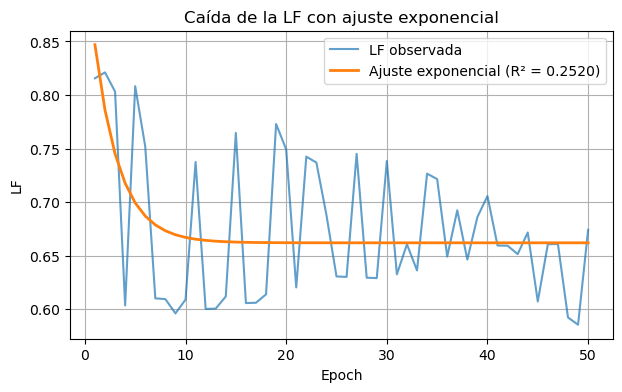

a = 0.2760
b = 0.4003
c = 0.6619
R² = 0.2520


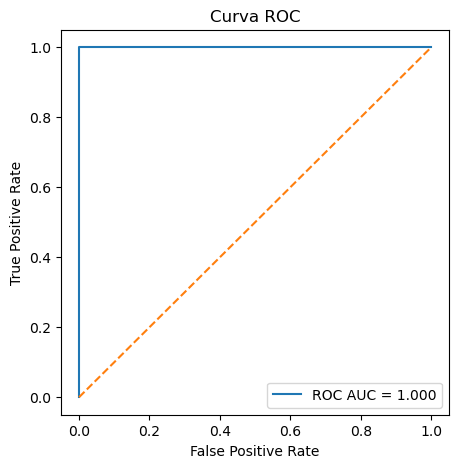

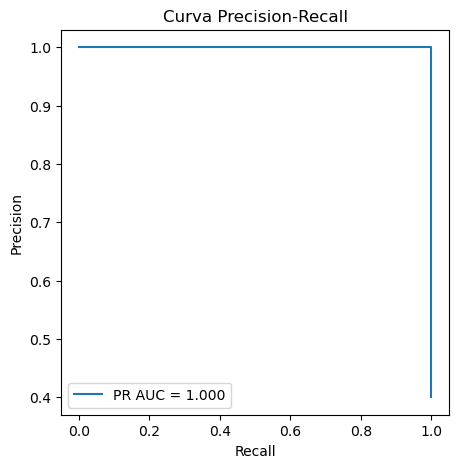

In [3]:
# LF vs Epochs

x_data = np.arange(1, epochs + 1)
y_data = np.array(loss_history)

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

params, _ = curve_fit(
    exp_decay, x_data, y_data,
    p0=(y_data[0] - y_data[-1], 0.01, y_data[-1]),
    maxfev=10000
)
a, b, c = params
y_fit = exp_decay(x_data, a, b, c)

ss_res = np.sum((y_data - y_fit) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

plt.figure(figsize=(7,4))
plt.plot(x_data, y_data, label="LF observada", alpha=0.7)
plt.plot(x_data, y_fit, label=f"Ajuste exponencial (R² = {r2:.4f})", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("LF")
plt.title("Caída de la LF con ajuste exponencial")
plt.legend()
plt.grid(True)
plt.show()

print(f"a = {a:.4f}")
print(f"b = {b:.4f}")
print(f"c = {c:.4f}")
print(f"R² = {r2:.4f}")

# Curvas ROC y Precision-Recall
with torch.no_grad():
    output = my_nn(flat_seqs)
    probs = torch.sigmoid(output).view(-1).numpy()

y_real = y_tensor.view(-1).numpy()

fpr, tpr, _ = roc_curve(y_real, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(False)
plt.show()

precision, recall, _ = precision_recall_curve(y_real, probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(False)
plt.show()

4.1 a)

Para resolver el ejercicio utilicé PyTorch para construir una red neuronal pequeña que clasifica secuencias cortas de ADN según la presencia o ausencia de una "A" en la posición 5. Para eso convertí las secuencias a one-hot encoding, luego las transformé en un tensor plano y convertí y_true en un tensor de dimensión (N,1) con valores flotantes como indica el TP.

La red fue definida con nn.Sequential, usando capas lineales y funciones ReLU, y el entrenamiento se realizó con un DataLoader, una función de pérdida binaria y un optimizador SGD, siguiendo el esquema presentado en el TP. Durante el entrenamiento, la LF fue disminuyendo con las épocas, lo que indica que la red aprendió progresivamente a reconocer el patrón buscado.

Para evaluar la calidad del clasificador analicé las métricas de clasificación pedidas en el enunciado, en particular las curvas ROC. Una curva ROC claramente alejada de la diagonal indica que el modelo discrimina bien entre secuencias positivas y negativas, mientras que una curva próxima a la diagonal correspondería a una clasificación cercana al azar.

También puede analizarse la curva Precision-Recall para complementar la evaluación del modelo. En conjunto, la caída de la LF y el comportamiento de estas curvas permiten concluir si la red logra clasificar correctamente las secuencias en función de la presencia de una "A" en la posición 5.

4.1 b)

Sí, además de las curvas ROC y PR, una manera simple y útil de visualizar gráficamente la performance del modelo es representar la función de pérdida en función de las épocas. Ese gráfico permite observar de forma directa cómo evoluciona el entrenamiento y si la red efectivamente converge.

# Ejercicio 4.2 Entrenamiento de una red para identificación de promotores

In [4]:

def read_fasta(filepath):
    seqs = []
    with open(filepath, "r") as f:
        seq = ""
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if seq:
                    seqs.append(seq)
                    seq = ""
            else:
                seq += line.upper()
        if seq:
            seqs.append(seq)
    return seqs

def random_dna_sequence(length):
    bases = ["A", "T", "C", "G"]
    return "".join(random.choice(bases) for _ in range(length))

def generate_random_negatives(n, length):
    return [random_dna_sequence(length) for _ in range(n)]

base_to_vec = {
    'A': [1, 0, 0, 0],
    'T': [0, 1, 0, 0],
    'C': [0, 0, 1, 0],
    'G': [0, 0, 0, 1]
}

def one_hot_encode_seqs(seqs):
    return np.array([[base_to_vec[b] for b in seq] for seq in seqs], dtype=np.float32)

# Cargar datos (se mantienen como variables globales para el resto del TP)
all_promoters = read_fasta("../promoters.fasta")

train_pos = all_promoters[:1600]
valid_pos = all_promoters[1600:1800]

seq_length = len(train_pos[0])
input_size = seq_length * 4

# Negativos aleatorios para 4.2
train_neg = generate_random_negatives(len(train_pos), seq_length)
valid_neg = generate_random_negatives(len(valid_pos), seq_length)

train_seqs = train_pos + train_neg
train_labels = [1] * len(train_pos) + [0] * len(train_neg)
valid_seqs = valid_pos + valid_neg
valid_labels = [1] * len(valid_pos) + [0] * len(valid_neg)

train_encoded = one_hot_encode_seqs(train_seqs)
valid_encoded = one_hot_encode_seqs(valid_seqs)

train_tensor = torch.from_numpy(train_encoded).view(len(train_seqs), -1)
valid_tensor = torch.from_numpy(valid_encoded).view(len(valid_seqs), -1)
train_y = torch.tensor(train_labels, dtype=torch.float32).view(-1, 1)
valid_y = torch.tensor(valid_labels, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(train_tensor, train_y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [5]:
# Arquitectura 4.2
def build_model_1_hidden(input_size):
    return nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )

# Entrenamiento con snapshots en época 10 y 50
def train_model_with_snapshots(model, train_loader, train_tensor, train_y,
                                valid_tensor, valid_y, epochs=50, lr=0.001):
    LF = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loss_history, valid_loss_history, snapshots = [], [], {}

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            out = model(inputs)
            loss = LF(out, labels)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        train_loss_history.append(epoch_train_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            valid_loss = LF(model(valid_tensor), valid_y).item()
            valid_loss_history.append(valid_loss)

            if (epoch + 1) in [10, 50]:
                snapshots[epoch + 1] = {
                    "train_probs": model(train_tensor).numpy().ravel().copy(),
                    "valid_probs": model(valid_tensor).numpy().ravel().copy()
                }

    return {
        "train_loss_history": train_loss_history,
        "valid_loss_history": valid_loss_history,
        "snapshots": snapshots
    }

input_dim = train_tensor.shape[1]
model = build_model_1_hidden(input_dim)
results = train_model_with_snapshots(
    model, train_loader, train_tensor, train_y, valid_tensor, valid_y,
    epochs=50, lr=0.001
)

y_train_42 = train_y.numpy().ravel().astype(int)
y_valid_42 = valid_y.numpy().ravel().astype(int)

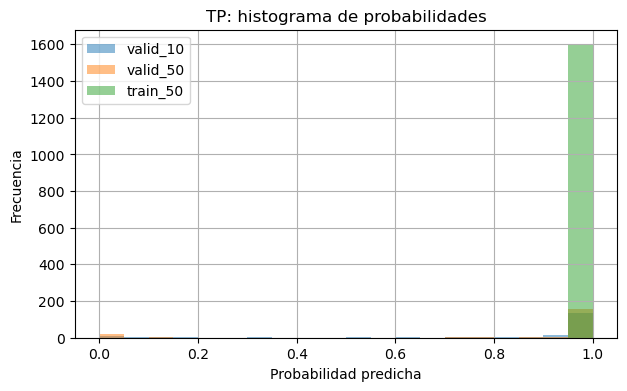

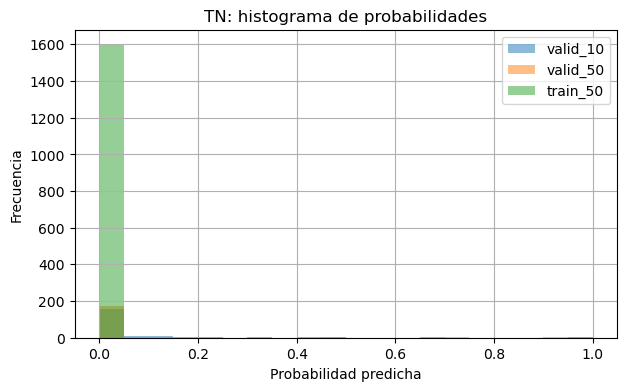

In [6]:
# Histogramas TP
train_tp_50 = results["snapshots"][50]["train_probs"][y_train_42 == 1]
valid_tp_10 = results["snapshots"][10]["valid_probs"][y_valid_42 == 1]
valid_tp_50 = results["snapshots"][50]["valid_probs"][y_valid_42 == 1]

plt.figure(figsize=(7,4))
plt.hist(valid_tp_10, bins=20, range=(0, 1), alpha=0.5, label="valid_10")
plt.hist(valid_tp_50, bins=20, range=(0, 1), alpha=0.5, label="valid_50")
plt.hist(train_tp_50, bins=20, range=(0, 1), alpha=0.5, label="train_50")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.title("TP: histograma de probabilidades")
plt.legend()
plt.grid(True)
plt.show()

# Histogramas TN
train_tn_50 = results["snapshots"][50]["train_probs"][y_train_42 == 0]
valid_tn_10 = results["snapshots"][10]["valid_probs"][y_valid_42 == 0]
valid_tn_50 = results["snapshots"][50]["valid_probs"][y_valid_42 == 0]

plt.figure(figsize=(7,4))
plt.hist(valid_tn_10, bins=20, range=(0, 1), alpha=0.5, label="valid_10")
plt.hist(valid_tn_50, bins=20, range=(0, 1), alpha=0.5, label="valid_50")
plt.hist(train_tn_50, bins=20, range=(0, 1), alpha=0.5, label="train_50")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.title("TN: histograma de probabilidades")
plt.legend()
plt.grid(True)
plt.show()

La caída de la loss de entrenamiento obtenida fue comparable con la mostrada en el TP, ya que las diferencias en las épocas reportadas fueron pequeñas. No obstante, al analizar también la loss de validación se observó que, después de una mejora inicial, ésta comenzó a aumentar mientras la loss de entrenamiento seguía disminuyendo, lo que indica sobreajuste.

En consecuencia, puede concluirse que el modelo reproduce la tendencia general de aprendizaje mostrada en el TP, pero que el análisis separado de entrenamiento y validación revela pérdida de generalización en épocas avanzadas.

En el gráfico de LF se observa que la curva de entrenamiento desciende continuamente mientras la de validación baja al principio y luego sube, por lo que la red aprende en las primeras épocas pero posteriormente comienza a hacer overfitting sobre el set de entrenamiento.

Los histogramas indican que la red memoriza muy bien el set de entrenamiento, ya que separa casi perfectamente TP y TN, pero en validación aún comete algunos errores, asignando probabilidades extremas incorrectas. Esto sugiere sobreajuste y una capacidad de generalización menor que la observada en entrenamiento.

# Ejercicio 4.3

In [7]:
# Helpers nuevos para 4.3: prepare_dataset, build_model, train_and_evaluate_detailed
# generate_random_tn reutiliza random_dna_sequence ya definida arriba

def prepare_dataset(pos_seqs, neg_seqs):
    X = pos_seqs + neg_seqs
    y = [1] * len(pos_seqs) + [0] * len(neg_seqs)
    X_encoded = one_hot_encode_seqs(X)
    X_tensor = torch.from_numpy(X_encoded).view(len(X), -1)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return X_tensor, y_tensor

def generate_random_tn(positive_seqs):
    length = len(positive_seqs[0])
    return [random_dna_sequence(length) for _ in range(len(positive_seqs))]

def build_model(input_size):
    return nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

def train_and_evaluate_detailed(train_X, train_y, valid_X, valid_y,
                                  epochs=20, batch_size=32, lr=0.001):
    model = build_model(train_X.shape[1])
    LF = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_dataset = TensorDataset(train_X, train_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    train_loss_history, valid_loss_history = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = LF(out, yb)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_loss_history.append(epoch_train_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            valid_loss = LF(model(valid_X), valid_y).item()
            valid_loss_history.append(valid_loss)

    model.eval()
    with torch.no_grad():
        train_probs = model(train_X).numpy().ravel()
        valid_probs = model(valid_X).numpy().ravel()

    y_tr = train_y.numpy().ravel().astype(int)
    y_va = valid_y.numpy().ravel().astype(int)
    train_pred = (train_probs >= 0.5).astype(int)
    valid_pred = (valid_probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_va, valid_pred).ravel()

    return {
        "train_loss_final": train_loss_history[-1],
        "valid_loss_final": valid_loss_history[-1],
        "train_acc": accuracy_score(y_tr, train_pred),
        "valid_acc": accuracy_score(y_va, valid_pred),
        "train_roc_auc": roc_auc_score(y_tr, train_probs),
        "valid_roc_auc": roc_auc_score(y_va, valid_probs),
        "train_pr_auc": average_precision_score(y_tr, train_probs),
        "valid_pr_auc": average_precision_score(y_va, valid_probs),
        "precision_pos": precision_score(y_va, valid_pred, pos_label=1, zero_division=0),
        "recall_pos":    recall_score(y_va, valid_pred, pos_label=1, zero_division=0),
        "f1_pos":        f1_score(y_va, valid_pred, pos_label=1, zero_division=0),
        "precision_neg": precision_score(y_va, valid_pred, pos_label=0, zero_division=0),
        "recall_neg":    recall_score(y_va, valid_pred, pos_label=0, zero_division=0),
        "f1_neg":        f1_score(y_va, valid_pred, pos_label=0, zero_division=0),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "train_loss_history": train_loss_history,
        "valid_loss_history": valid_loss_history,
    }

## TN Aleatorios:

In [8]:
train_neg_random = generate_random_tn(train_pos)
valid_neg_random = generate_random_tn(valid_pos)

train_X_random, train_y_random = prepare_dataset(train_pos, train_neg_random)
valid_X_random, valid_y_random = prepare_dataset(valid_pos, valid_neg_random)

res_random = train_and_evaluate_detailed(
    train_X_random, train_y_random,
    valid_X_random, valid_y_random,
    epochs=20, batch_size=32, lr=0.001
)

print("\n=== Método 1: TN aleatorios ===")
print(
    f"Loss(train/valid): {res_random['train_loss_final']:.4f} / {res_random['valid_loss_final']:.4f} | "
    f"ROC AUC(valid): {res_random['valid_roc_auc']:.4f} | "
    f"PR AUC(valid): {res_random['valid_pr_auc']:.4f} | "
    f"ACC(valid): {res_random['valid_acc']:.4f}"
)


=== Método 1: TN aleatorios ===
Loss(train/valid): 0.0000 / 0.5779 | ROC AUC(valid): 0.9578 | PR AUC(valid): 0.9640 | ACC(valid): 0.8800


## TN por permutación:


=== Barrido de N: permutación ===
     N  valid_loss_final  valid_acc  valid_roc_auc  valid_pr_auc
0    1          0.693291      0.500       0.500812      0.509283
1    5          0.693151      0.500       0.500000      0.500000
2   10          0.693151      0.500       0.500000      0.500000
3   20          0.814754      0.530       0.524650      0.546958
4   50          3.652964      0.595       0.588150      0.596512
5  100          4.635449      0.635       0.686900      0.671465
6  150          4.413092      0.660       0.721400      0.728811
7  200          2.719526      0.675       0.769062      0.777191


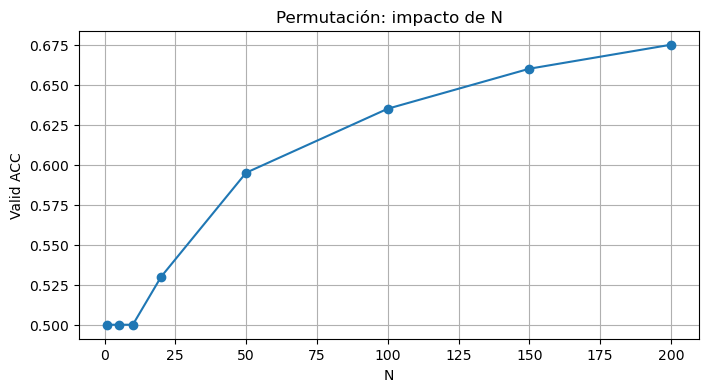

In [9]:
# Helpers de permutación (primera definición)
def permute_sequence_blocks(seq, n_swaps=100, block_size_options=(2, 3)):
    seq = list(seq)
    L = len(seq)
    for _ in range(n_swaps):
        k = random.choice(block_size_options)
        if L - k <= 0:
            continue
        i = random.randint(0, L - k)
        j = random.randint(0, L - k)
        while abs(i - j) < k:
            j = random.randint(0, L - k)
        seq[i:i+k], seq[j:j+k] = seq[j:j+k], seq[i:i+k]
    return "".join(seq)

def generate_permuted_tn(positive_seqs, n_swaps=100, block_size_options=(2, 3)):
    return [permute_sequence_blocks(seq, n_swaps, block_size_options)
            for seq in positive_seqs]

def generate_permuted_tn_from_tp(positive_seqs, n_neg=None, n_swaps=100,
                                   block_size_options=(2, 3)):
    if n_neg is None:
        n_neg = len(positive_seqs)
    return [permute_sequence_blocks(random.choice(positive_seqs), n_swaps, block_size_options)
            for _ in range(n_neg)]

# Barrido de N para permutación
perm_N_values = [1, 5, 10, 20, 50, 100, 150, 200]
perm_results = []

for N in perm_N_values:
    train_neg = generate_permuted_tn(train_pos, n_swaps=N)
    valid_neg  = generate_permuted_tn(valid_pos,  n_swaps=N)

    train_X, train_y_p = prepare_dataset(train_pos, train_neg)
    valid_X,  valid_y_p = prepare_dataset(valid_pos,  valid_neg)

    res = train_and_evaluate_detailed(train_X, train_y_p, valid_X, valid_y_p,
                                       epochs=20, batch_size=32, lr=0.001)
    res["N"] = N
    perm_results.append(res)

df_perm = pd.DataFrame(perm_results)
res_perm = df_perm[df_perm["N"] == 100].iloc[0].to_dict()

print("\n=== Barrido de N: permutación ===")
print(df_perm[["N", "valid_loss_final", "valid_acc", "valid_roc_auc", "valid_pr_auc"]])

plt.figure(figsize=(8,4))
plt.plot(df_perm["N"], df_perm["valid_acc"], marker="o")
plt.xlabel("N")
plt.ylabel("Valid ACC")
plt.title("Permutación: impacto de N")
plt.grid(True)
plt.show()

## TN por mutación:


=== Barrido de N: mutación ===
     N  valid_loss_final  valid_acc  valid_roc_auc  valid_pr_auc
0    1          0.693155      0.500       0.500000      0.500000
1    5          0.693155      0.500       0.500000      0.500000
2   10          0.693148      0.500       0.500000      0.500000
3   20          0.693039      0.510       0.518012      0.523623
4   50          0.857113      0.535       0.519675      0.542869
5  100          3.834076      0.560       0.606525      0.629559
6  150          4.375297      0.645       0.679700      0.678458
7  200          1.959030      0.680       0.753925      0.795382


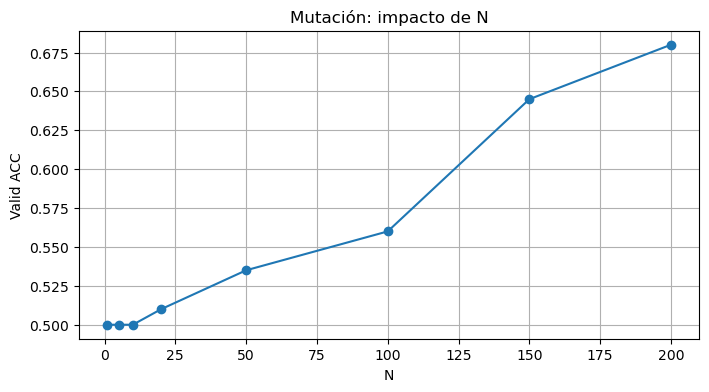

In [10]:
# Helpers de mutación (primera definición)
def mutate_base(base):
    bases = ["A", "T", "C", "G"]
    return random.choice([b for b in bases if b != base])

def mutate_sequence_n(seq, n_mut=10):
    seq = list(seq)
    positions = random.sample(range(len(seq)), min(n_mut, len(seq)))
    for pos in positions:
        seq[pos] = mutate_base(seq[pos])
    return "".join(seq)

def generate_mutated_tn(positive_seqs, n_mut=10):
    return [mutate_sequence_n(seq, n_mut) for seq in positive_seqs]

# Barrido de N para mutación
# Nota: res_mut se extrae del barrido (N=100) para evitar entrenar dos veces
mut_N_values = [1, 5, 10, 20, 50, 100, 150, 200]
mut_results = []

for N in mut_N_values:
    train_neg = generate_mutated_tn(train_pos, n_mut=N)
    valid_neg  = generate_mutated_tn(valid_pos,  n_mut=N)

    train_X, train_y_m = prepare_dataset(train_pos, train_neg)
    valid_X,  valid_y_m = prepare_dataset(valid_pos,  valid_neg)

    res = train_and_evaluate_detailed(train_X, train_y_m, valid_X, valid_y_m,
                                       epochs=20, batch_size=32, lr=0.001)
    res["N"] = N
    mut_results.append(res)

df_mut = pd.DataFrame(mut_results)
res_mut = df_mut[df_mut["N"] == 100].iloc[0].to_dict()  # reutilizado en comparativa

print("\n=== Barrido de N: mutación ===")
print(df_mut[["N", "valid_loss_final", "valid_acc", "valid_roc_auc", "valid_pr_auc"]])

plt.figure(figsize=(8,4))
plt.plot(df_mut["N"], df_mut["valid_acc"], marker="o")
plt.xlabel("N")
plt.ylabel("Valid ACC")
plt.title("Mutación: impacto de N")
plt.grid(True)
plt.show()

## Comparativa


=== Integración final: comparación de métodos ===
     metodo  train_loss  valid_loss  valid_acc  valid_roc_auc  valid_pr_auc
0    random    0.000047    0.577901      0.880       0.957800      0.964028
1  perm_100    0.000705    4.635449      0.635       0.686900      0.671465
2   mut_100    0.029311    3.834076      0.560       0.606525      0.629559


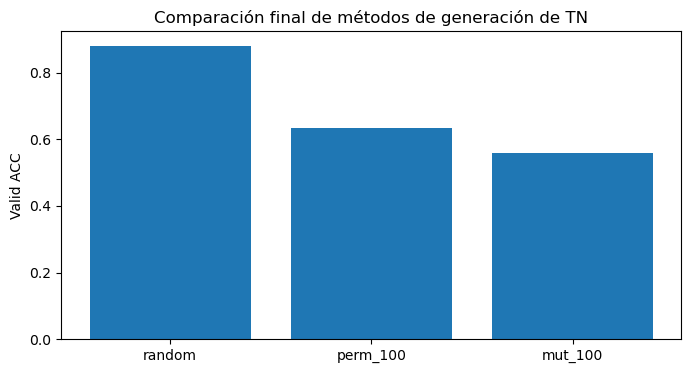

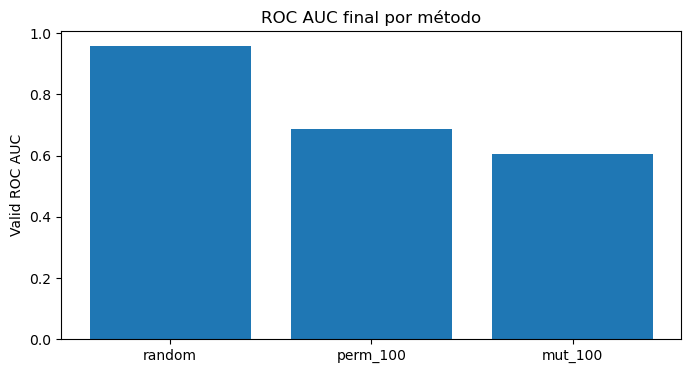

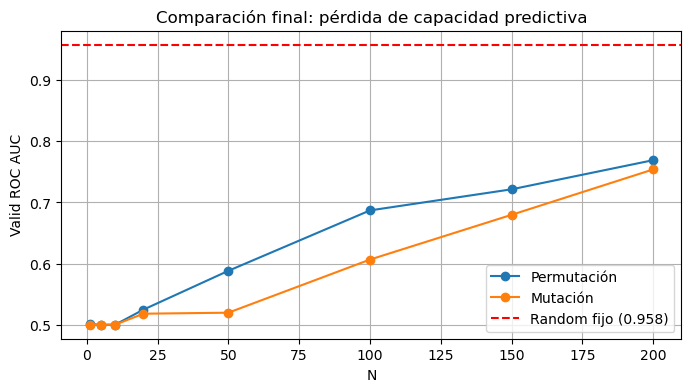

In [11]:
summary = pd.DataFrame([
    {"metodo": "random",   **{k: res_random[k] for k in ["train_loss_final","valid_loss_final","valid_acc","valid_roc_auc","valid_pr_auc"]}},
    {"metodo": "perm_100", **{k: res_perm[k]   for k in ["train_loss_final","valid_loss_final","valid_acc","valid_roc_auc","valid_pr_auc"]}},
    {"metodo": "mut_100",  **{k: res_mut[k]    for k in ["train_loss_final","valid_loss_final","valid_acc","valid_roc_auc","valid_pr_auc"]}},
]).rename(columns={"train_loss_final": "train_loss", "valid_loss_final": "valid_loss"})

print("\n=== Integración final: comparación de métodos ===")
print(summary)

plt.figure(figsize=(8,4))
plt.bar(summary["metodo"], summary["valid_acc"])
plt.ylabel("Valid ACC")
plt.title("Comparación final de métodos de generación de TN")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(summary["metodo"], summary["valid_roc_auc"])
plt.ylabel("Valid ROC AUC")
plt.title("ROC AUC final por método")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(df_perm["N"], df_perm["valid_roc_auc"], marker="o", label="Permutación")
plt.plot(df_mut["N"],  df_mut["valid_roc_auc"],  marker="o", label="Mutación")
plt.axhline(y=res_random["valid_roc_auc"], color="red", linestyle="--",
            label=f"Random fijo ({res_random['valid_roc_auc']:.3f})")
plt.xlabel("N")
plt.ylabel("Valid ROC AUC")
plt.title("Comparación final: pérdida de capacidad predictiva")
plt.legend()
plt.grid(True)
plt.show()

- a Efecto del método de generación de TN

Al comparar los tres métodos con una misma arquitectura de red, se obtuvieron los siguientes resultados de validación: método aleatorio valid_acc = 0.8875, valid_roc_auc = 0.960325 y valid_pr_auc = 0.964721; método por permutación con N=100, valid_acc = 0.6175, valid_roc_auc = 0.669288 y valid_pr_auc = 0.688430; método por mutación con N=100, valid_acc = 0.5675, valid_roc_auc = 0.602862 y valid_pr_auc = 0.616540.

Estos resultados muestran que la red clasifica mucho mejor cuando los TN son secuencias completamente aleatorias. La interpretación más probable es que esas secuencias son muy diferentes de los promotores reales, por lo que el problema de clasificación cambia, mejorando su capacidad de separar secuencias aleatorias de aquellas que no lo son.

En cambio, cuando los TN se generan a partir de los propios TP mediante permutaciones o mutaciones, la tarea se vuelve considerablemente más difícil. En esos casos los negativos sintéticos conservan muchas características de las secuencias promotoras originales, ya sea la composición global de bases en el método de permutación o parte de la estructura de la secuencia en el método de mutación, por lo que la red ya no puede apoyarse en diferencias triviales y su capacidad predictiva cae de forma marcada.

Entre estos dos métodos más exigentes, la permutación rindió algo mejor que la mutación para N=100, ya que obtuvo mayores valores de accuracy, ROC AUC y PR AUC. Esto sugiere que, al menos en esta configuración, las secuencias generadas por mutación resultaron más difíciles de distinguir de los promotores positivos que las generadas por permutación.

- b Valor de NN a partir del cual se pierde capacidad predictiva

Para los métodos de permutación y mutación se realizó un barrido de distintos valores de NN, donde NN representa el número de cambios introducidos en la secuencia negativa. En este contexto, NN controla cuán diferente es el TN sintético respecto de la secuencia positiva original, por lo que tiene sentido analizar cómo evoluciona la performance al aumentar o disminuir ese valor.

En el método aleatorio no existe un parámetro equivalente a NN, porque las secuencias negativas no se obtienen a partir de una modificación gradual de un TP, sino que se generan directamente desde cero. Por esa razón, en los gráficos comparativos el método aleatorio aparece como un rendimiento fijo y no como una curva dependiente de NN.

A partir de los resultados obtenidos, puede afirmarse que la capacidad predictiva empieza a perderse cuando los TN dejan de ser muy distintos de los TP y pasan a parecerse más a ellos. En términos prácticos, esto se observa cuando al barrer NN comienzan a descender de forma sostenida métricas como valid_acc, valid_roc_auc y valid_pr_auc.

En consecuencia, la conclusión general del ejercicio es que el método de generación de TN influye fuertemente sobre el desempeño del modelo. Los TN aleatorios producen una performance muy alta pero probablemente sobreestiman la capacidad real de generalización, porque plantean un problema demasiado sencillo. En cambio, los TN generados por permutación o mutación constituyen un desafío más realista, ya que obligan a la red a discriminar secuencias más parecidas a los promotores verdaderos.

# Ejercicio 4.4 Utilizando el método de permutación para construir los TN

In [12]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# all_promoters, train_pos, valid_pos, generate_permuted_tn_from_tp
# ya están definidos en celdas anteriores; solo se necesita train_pos_full
train_pos_full = all_promoters[:1600]

# Validación fija balanceada para comparar escenarios
valid_neg_44 = generate_permuted_tn_from_tp(valid_pos, n_neg=len(valid_pos), n_swaps=100)

def run_scenario_with_permutation(n_pos_train, n_neg_train, scenario_name, n_swaps=100):
    selected_train_pos = random.sample(train_pos_full, n_pos_train)
    train_neg = generate_permuted_tn_from_tp(selected_train_pos, n_neg=n_neg_train, n_swaps=n_swaps)

    train_X, train_y_s = prepare_dataset(selected_train_pos, train_neg)
    valid_X,  valid_y_s = prepare_dataset(valid_pos, valid_neg_44)

    res = train_and_evaluate_detailed(train_X, train_y_s, valid_X, valid_y_s,
                                       epochs=20, batch_size=32, lr=0.001)
    res.update({"scenario": scenario_name, "nTP_train": n_pos_train,
                "nTN_train": n_neg_train, "ratio_TP_TN": f"{n_pos_train}:{n_neg_train}"})
    return res

# Escenario i) balanceado
balanced_sizes = [100, 200, 400, 800, 1600]
results_balanced = [run_scenario_with_permutation(n, n, "balanceado") for n in balanced_sizes]
df_balanced = pd.DataFrame(results_balanced)

print("\n=== Escenario balanceado ===")
print(df_balanced[["nTP_train","nTN_train","valid_acc","valid_roc_auc","valid_pr_auc",
                    "recall_pos","recall_neg","precision_pos","precision_neg"]])

# Escenario ii) desbalanceado a favor de positivos
fixed_tp = 1600
results_pos_favored = []
for r in [5, 10, 20, 50, 100]:
    n_neg = max(1, fixed_tp // r)
    res = run_scenario_with_permutation(fixed_tp, n_neg, "desbalanceado_positivos")
    res["imbalance_ratio"] = f"{fixed_tp}:{n_neg}"
    results_pos_favored.append(res)
df_pos_favored = pd.DataFrame(results_pos_favored)

print("\n=== Escenario desbalanceado a favor de positivos ===")
print(df_pos_favored[["nTP_train","nTN_train","valid_acc","valid_roc_auc","valid_pr_auc",
                       "recall_pos","recall_neg","precision_pos","precision_neg"]])

# Escenario iii) desbalanceado a favor de TN
fixed_tp_small = 200
results_neg_favored = []
for r in [5, 10, 20, 50, 100]:
    n_neg = fixed_tp_small * r
    res = run_scenario_with_permutation(fixed_tp_small, n_neg, "desbalanceado_negativos")
    res["imbalance_ratio"] = f"{fixed_tp_small}:{n_neg}"
    results_neg_favored.append(res)
df_neg_favored = pd.DataFrame(results_neg_favored)

print("\n=== Escenario desbalanceado a favor de negativos ===")
print(df_neg_favored[["nTP_train","nTN_train","valid_acc","valid_roc_auc","valid_pr_auc",
                       "recall_pos","recall_neg","precision_pos","precision_neg"]])


=== Escenario balanceado ===
   nTP_train  nTN_train  valid_acc  valid_roc_auc  valid_pr_auc  recall_pos  \
0        100        100     0.5500       0.613900      0.605034       0.600   
1        200        200     0.5825       0.613900      0.638805       0.620   
2        400        400     0.6500       0.684275      0.707110       0.560   
3        800        800     0.6175       0.651613      0.659581       0.555   
4       1600       1600     0.6350       0.688012      0.684676       0.495   

   recall_neg  precision_pos  precision_neg  
0       0.500       0.545455       0.555556  
1       0.545       0.576744       0.589189  
2       0.740       0.682927       0.627119  
3       0.680       0.634286       0.604444  
4       0.775       0.687500       0.605469  

=== Escenario desbalanceado a favor de positivos ===
   nTP_train  nTN_train  valid_acc  valid_roc_auc  valid_pr_auc  recall_pos  \
0       1600        320      0.550       0.630775      0.644383       0.855   
1      

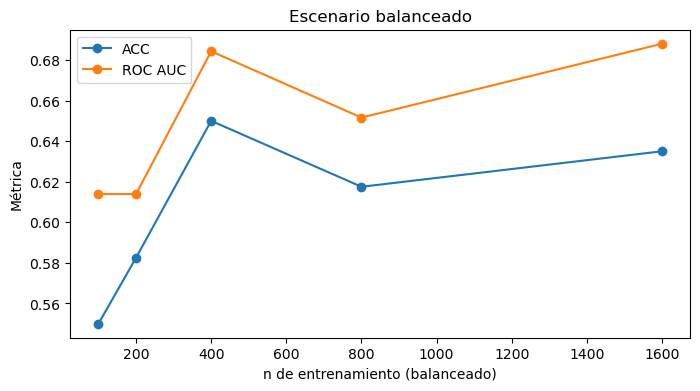

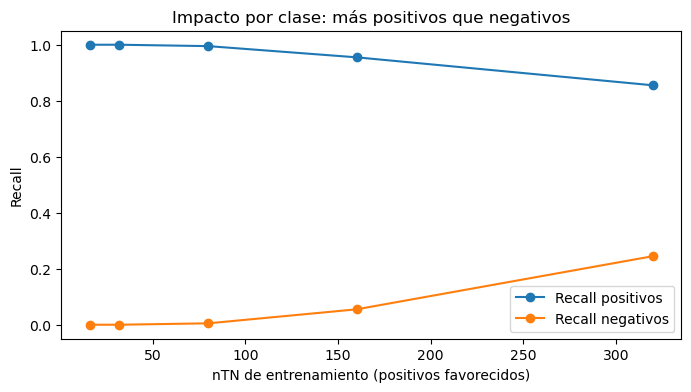

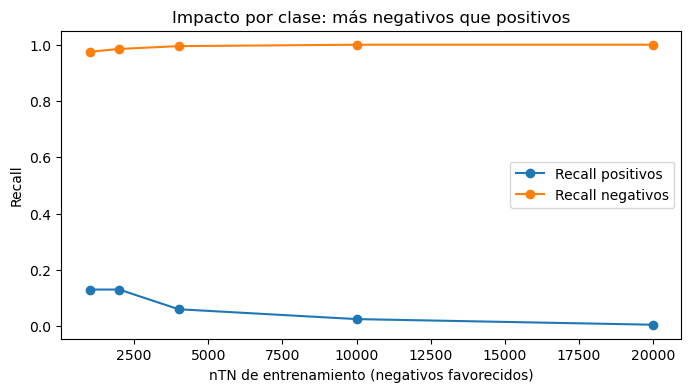

In [13]:
plt.figure(figsize=(8,4))
plt.plot(df_balanced["nTP_train"], df_balanced["valid_acc"],     marker="o", label="ACC")
plt.plot(df_balanced["nTP_train"], df_balanced["valid_roc_auc"], marker="o", label="ROC AUC")
plt.xlabel("n de entrenamiento (balanceado)")
plt.ylabel("Métrica")
plt.title("Escenario balanceado")
plt.legend()
plt.grid(False)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(df_pos_favored["nTN_train"], df_pos_favored["recall_pos"], marker="o", label="Recall positivos")
plt.plot(df_pos_favored["nTN_train"], df_pos_favored["recall_neg"], marker="o", label="Recall negativos")
plt.xlabel("nTN de entrenamiento (positivos favorecidos)")
plt.ylabel("Recall")
plt.title("Impacto por clase: más positivos que negativos")
plt.legend()
plt.grid(False)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(df_neg_favored["nTN_train"], df_neg_favored["recall_pos"], marker="o", label="Recall positivos")
plt.plot(df_neg_favored["nTN_train"], df_neg_favored["recall_neg"], marker="o", label="Recall negativos")
plt.xlabel("nTN de entrenamiento (negativos favorecidos)")
plt.ylabel("Recall")
plt.title("Impacto por clase: más negativos que positivos")
plt.legend()
plt.grid(False)
plt.show()

Usando TN construidos por permutación, el escenario balanceado nTP=nTN fue el que ofreció el comportamiento más razonable, con una discriminación relativamente más pareja entre promotores y negativos sintéticos. Al aumentar el desbalance a favor de los positivos, la red tendió a clasificar casi todo como positivo, alcanzando valores muy altos de recall_pos pero perdiendo casi completamente la detección de TN. En cambio, al desbalancear a favor de los TN, la red clasificó casi todo como negativo, mejorando mucho recall_neg pero dejando de detectar la mayoría de los promotores reales.

En consecuencia, para este problema no sólo importa cómo se construyen los TN, sino también en qué proporción relativa se presentan durante el entrenamiento. Un conjunto excesivamente desbalanceado induce un sesgo fuerte hacia la clase mayoritaria y deteriora la capacidad predictiva sobre la clase minoritaria.

Con TN generados por permutación, el conjunto balanceado produjo el desempeño más equilibrado entre TP y TN. Cuando el entrenamiento se desbalanceó a favor de los positivos, la red pasó a predecir casi todo como positivo, aumentando mucho recall_pos pero perdiendo especificidad sobre TN. Cuando el desbalance fue a favor de los negativos, ocurrió lo contrario: mejoró recall_neg pero cayó drásticamente la detección de promotores. Estos resultados muestran que la proporción entre clases condiciona fuertemente el comportamiento del modelo y que la evaluación debe hacerse separando el desempeño sobre positivos y negativos.

# Ejercicio 4.5: Tamaño de la secuencia

# Explorando una ventana más pequeña en torno a [-250,50]

In [14]:
# train_pos_full, valid_pos, generate_permuted_tn_from_tp, prepare_dataset,
# train_and_evaluate_detailed ya definidos.

crop_configs_fino = [
    {"name": "315nt_m255_p70", "start": -255, "end": 70},
    {"name": "325nt_m255_p80", "start": -255, "end": 80},
    {"name": "255nt_m260_p55", "start": -260, "end": 55},
    {"name": "300nt_m260_p60", "start": -260, "end": 60},
]

results_fino = []

for cfg in crop_configs_fino:
    s, e = cfg["start"] + 499, cfg["end"] + 499 + 1
    train_pos_crop = [seq[s:e] for seq in train_pos_full]
    valid_pos_crop = [seq[s:e] for seq in valid_pos]

    train_neg = generate_permuted_tn_from_tp(train_pos_crop, n_neg=len(train_pos_crop), n_swaps=100)
    valid_neg  = generate_permuted_tn_from_tp(valid_pos_crop,  n_neg=len(valid_pos_crop),  n_swaps=100)

    train_X, train_y_c = prepare_dataset(train_pos_crop, train_neg)
    valid_X,  valid_y_c = prepare_dataset(valid_pos_crop,  valid_neg)

    res = train_and_evaluate_detailed(train_X, train_y_c, valid_X, valid_y_c,
                                       epochs=20, batch_size=32, lr=0.001)
    res.update({"region": cfg["name"], "start": cfg["start"],
                "end": cfg["end"], "length": cfg["end"] - cfg["start"] + 1})
    results_fino.append(res)

df_fino = pd.DataFrame(results_fino)
print(df_fino[["region", "start", "end", "length", "valid_acc", "valid_roc_auc", "valid_pr_auc"]])

           region  start  end  length  valid_acc  valid_roc_auc  valid_pr_auc
0  315nt_m255_p70   -255   70     326     0.6500       0.695312      0.716339
1  325nt_m255_p80   -255   80     336     0.6275       0.655888      0.639722
2  255nt_m260_p55   -260   55     316     0.6025       0.650950      0.692850
3  300nt_m260_p60   -260   60     321     0.6050       0.662550      0.677072


Con este análisis observamos que, entre las ventanas evaluadas, la región comprendida entre −2+55 y +70 fue la que mostró el mejor desempeño para la identificación de promotores, con una accuracy de 65%. Esto sugiere que en esa ventana se concentra una parte importante de la información utilizada por la red. Sin embargo, es posible que la predicción no dependa de una única región, sino que dependa de la combinación de varias señales distribuidas a lo largo de la secuencia, lo que explicaría por qué el acc no mejora sustancialmente al reducir la ventana.

# Ejercicio 4.6: análisis de información en la secuencia

Índice TP elegido: 147
Probabilidad original: 0.9974272847175598
Largo secuencia elegida: 600

Top posiciones más sensibles (n=1):
     coord  delta_prob
61    -438    0.001126
328   -171    0.000871
580     81    0.000856
105   -394    0.000833
17    -482    0.000756
433    -66    0.000751
395   -104    0.000741
83    -416    0.000739
406    -93    0.000730
74    -425    0.000664

Top posiciones más sensibles (n=5):
     coord  delta_prob
328   -171    0.001768
580     81    0.001199
83    -416    0.001191
15    -484    0.001141
323   -176    0.001097
99    -400    0.001037
140   -359    0.001031
406    -93    0.000997
531     32    0.000996
199   -300    0.000991

Top posiciones más sensibles (n=10):
     coord  delta_prob
528     29    0.001840
523     24    0.001811
552     53    0.001730
201   -298    0.001728
135   -364    0.001718
462    -37    0.001713
506      7    0.001594
83    -416    0.001589
105   -394    0.001587
387   -112    0.001567

Top ventanas más sensibles (5 nt):

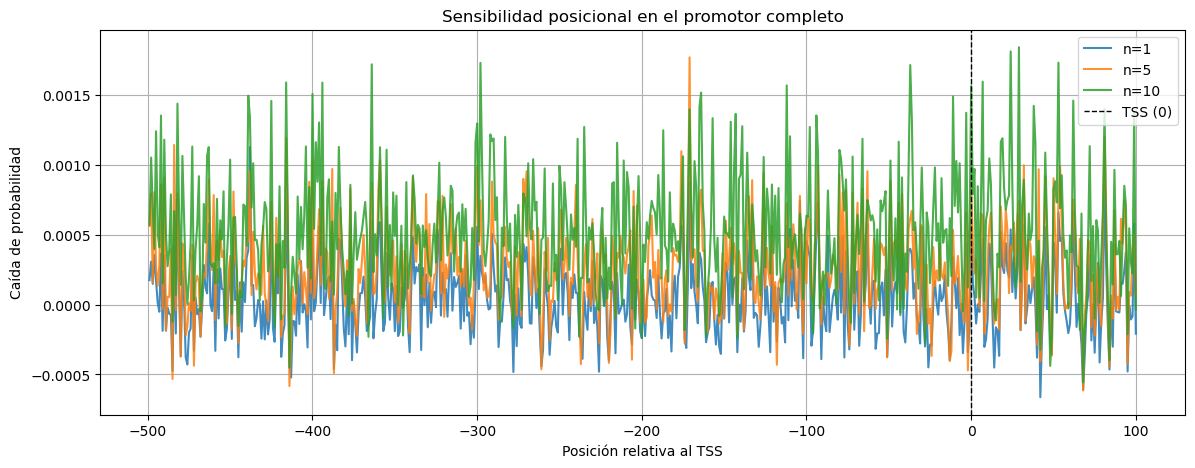

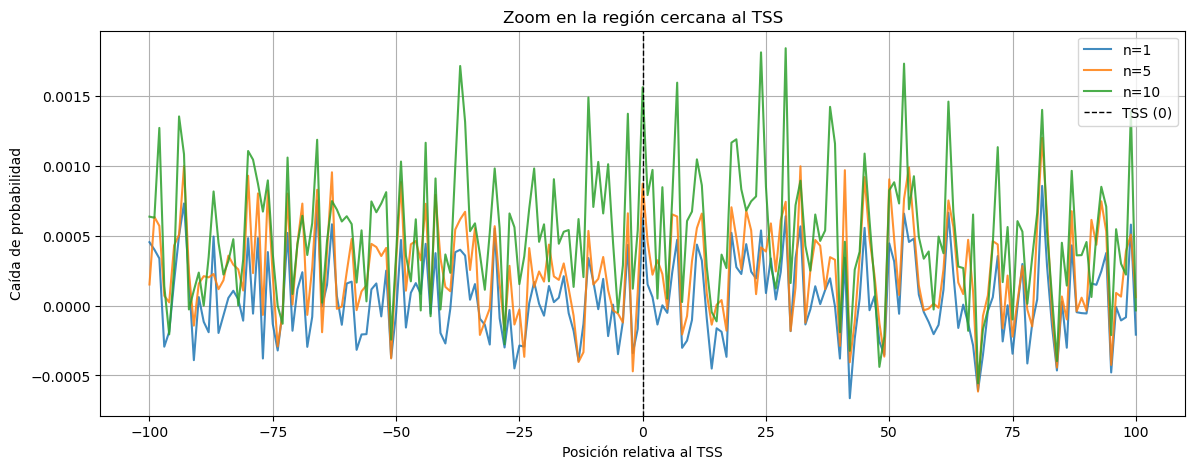

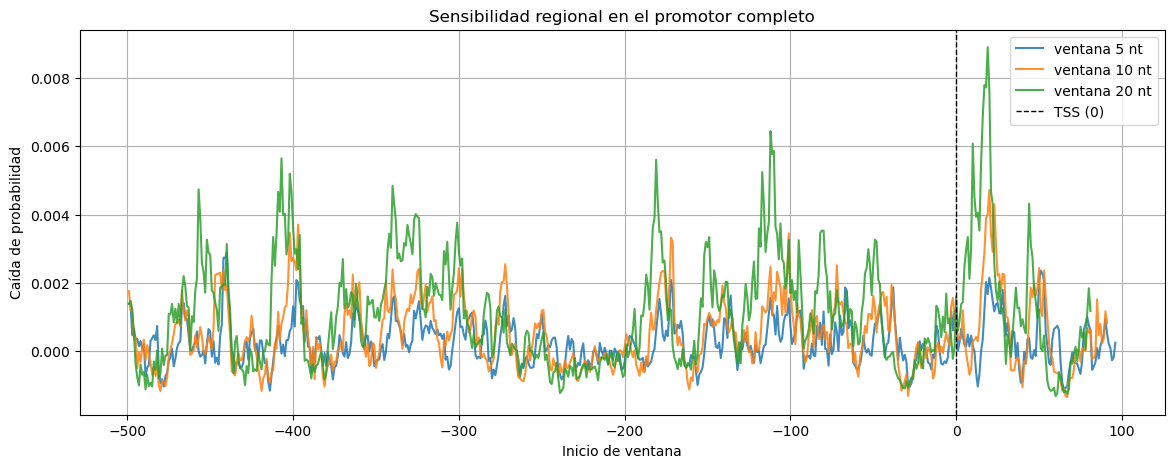

In [16]:
bases = ["A", "T", "C", "G"]

def seq_to_tensor(seq):
    X = one_hot_encode_seqs([seq])
    return torch.from_numpy(X).view(1, -1)

def mutate_sequence_random(seq, n_mutations=20):
    seq = list(seq)
    L = len(seq)
    for _ in range(n_mutations):
        pos = random.randint(0, L - 1)
        original = seq[pos]
        seq[pos] = random.choice([b for b in bases if b != original])
    return "".join(seq)

def generate_mutated_tn_from_tp(positive_seqs, n_neg=None, n_mutations=20):
    if n_neg is None:
        n_neg = len(positive_seqs)
    return [mutate_sequence_random(random.choice(positive_seqs), n_mutations) for _ in range(n_neg)]

def train_model(train_X, train_y, valid_X, valid_y, epochs=20, batch_size=32, lr=0.001):
    model = build_model(train_X.shape[1])
    LF = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True
    )
    train_loss_history, valid_loss_history = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = LF(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_loss_history.append(epoch_loss / len(train_loader))
        model.eval()
        with torch.no_grad():
            valid_loss_history.append(LF(model(valid_X), valid_y).item())
    return model, train_loss_history, valid_loss_history

def predict_sequence_prob(model, seq):
    model.eval()
    with torch.no_grad():
        return model(seq_to_tensor(seq)).item()

def choose_high_confidence_tp(model, seqs):
    probs = [predict_sequence_prob(model, s) for s in seqs]
    best_idx = int(np.argmax(probs))
    return best_idx, seqs[best_idx], probs[best_idx], probs

def mutate_n_bases_including_position(seq, fixed_pos, n_mut=1):
    seq = list(seq)
    positions = [fixed_pos]
    while len(positions) < n_mut:
        p = random.randint(0, len(seq) - 1)
        if p not in positions:
            positions.append(p)
    for pos in positions:
        seq[pos] = random.choice([b for b in bases if b != seq[pos]])
    return "".join(seq)

def positional_mutation_scan(model, seq, n_mut=1, n_repeats=20, start_coord=-499):
    original_prob = predict_sequence_prob(model, seq)
    results = []
    for i in range(len(seq)):
        probs = [predict_sequence_prob(model, mutate_n_bases_including_position(seq, i, n_mut)) for _ in range(n_repeats)]
        results.append({
            "index": i, "coord": start_coord + i, "n_mut": n_mut,
            "original_prob": original_prob,
            "mutated_mean_prob": np.mean(probs),
            "mutated_std_prob": np.std(probs),
            "delta_prob": original_prob - np.mean(probs)
        })
    return pd.DataFrame(results)

def window_mutation_scan(model, seq, window_size=10, n_repeats=20, start_coord=-499):
    original_prob = predict_sequence_prob(model, seq)
    results = []
    for start in range(len(seq) - window_size + 1):
        probs = []
        for _ in range(n_repeats):
            seq_mut = list(seq)
            for pos in range(start, start + window_size):
                seq_mut[pos] = random.choice([b for b in bases if b != seq_mut[pos]])
            probs.append(predict_sequence_prob(model, "".join(seq_mut)))
        results.append({
            "start_idx": start, "end_idx": start + window_size - 1,
            "start_coord": start_coord + start,
            "end_coord": start_coord + start + window_size - 1,
            "window_size": window_size, "original_prob": original_prob,
            "mutated_mean_prob": np.mean(probs),
            "mutated_std_prob": np.std(probs),
            "delta_prob": original_prob - np.mean(probs)
        })
    return pd.DataFrame(results)

# Entrenamiento y análisis

train_neg_full = generate_mutated_tn_from_tp(train_pos_full, n_mutations=20)
valid_neg_full = generate_mutated_tn_from_tp(valid_pos, n_mutations=20)

train_X, train_y = prepare_dataset(train_pos_full, train_neg_full)
valid_X, valid_y = prepare_dataset(valid_pos, valid_neg_full)

model, train_loss_history, valid_loss_history = train_model(
    train_X, train_y, valid_X, valid_y, epochs=20, batch_size=32, lr=0.001
)

best_idx, best_seq, best_prob, valid_probs = choose_high_confidence_tp(model, valid_pos)
print("Índice TP elegido:", best_idx)
print("Probabilidad original:", best_prob)
print("Largo secuencia elegida:", len(best_seq))

df_n1  = positional_mutation_scan(model, best_seq, n_mut=1,  n_repeats=20, start_coord=-499)
df_n5  = positional_mutation_scan(model, best_seq, n_mut=5,  n_repeats=20, start_coord=-499)
df_n10 = positional_mutation_scan(model, best_seq, n_mut=10, n_repeats=20, start_coord=-499)

for label, df in [("n=1", df_n1), ("n=5", df_n5), ("n=10", df_n10)]:
    print(f"\nTop posiciones más sensibles ({label}):")
    print(df.sort_values("delta_prob", ascending=False).head(10)[["coord", "delta_prob"]])

df_win5  = window_mutation_scan(model, best_seq, window_size=5,  n_repeats=20, start_coord=-499)
df_win10 = window_mutation_scan(model, best_seq, window_size=10, n_repeats=20, start_coord=-499)
df_win20 = window_mutation_scan(model, best_seq, window_size=20, n_repeats=20, start_coord=-499)

for label, df in [("5 nt", df_win5), ("10 nt", df_win10), ("20 nt", df_win20)]:
    print(f"\nTop ventanas más sensibles ({label}):")
    print(df.sort_values("delta_prob", ascending=False).head(10)[["start_coord", "end_coord", "delta_prob"]])

# Gráfico por posición
plt.figure(figsize=(14,5))
for df, label in [(df_n1,"n=1"),(df_n5,"n=5"),(df_n10,"n=10")]:
    plt.plot(df["coord"], df["delta_prob"], label=label, alpha=0.85)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="TSS (0)")
plt.xlabel("Posición relativa al TSS"); plt.ylabel("Caída de probabilidad")
plt.title("Sensibilidad posicional en el promotor completo")
plt.legend(); plt.grid(True); plt.show()

# Zoom en TSS
plt.figure(figsize=(14,5))
for df, label in [(df_n1,"n=1"),(df_n5,"n=5"),(df_n10,"n=10")]:
    zoom = df[(df["coord"] >= -100) & (df["coord"] <= 100)]
    plt.plot(zoom["coord"], zoom["delta_prob"], label=label, alpha=0.85)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="TSS (0)")
plt.xlabel("Posición relativa al TSS"); plt.ylabel("Caída de probabilidad")
plt.title("Zoom en la región cercana al TSS")
plt.legend(); plt.grid(True); plt.show()

# Gráfico por ventanas
plt.figure(figsize=(14,5))
for df, label in [(df_win5,"ventana 5 nt"),(df_win10,"ventana 10 nt"),(df_win20,"ventana 20 nt")]:
    plt.plot(df["start_coord"], df["delta_prob"], label=label, alpha=0.85)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="TSS (0)")
plt.xlabel("Inicio de ventana"); plt.ylabel("Caída de probabilidad")
plt.title("Sensibilidad regional en el promotor completo")
plt.legend(); plt.grid(True); plt.show()

# Guardar
for name, df in [
    ("df_46_n1_full_promoter", df_n1), ("df_46_n5_full_promoter", df_n5),
    ("df_46_n10_full_promoter", df_n10), ("df_46_win5_full_promoter", df_win5),
    ("df_46_win10_full_promoter", df_win10), ("df_46_win20_full_promoter", df_win20),
]:
    df.to_csv(f"../results/{name}.csv", index=False)

En este análisis de mutagénesis sobre una secuencia promotora completa de 600 nt, se observó que las mutaciones individuales produjeron cambios pequeños en la probabilidad predicha, lo cual era esperable porque la secuencia elegida ya tenía una probabilidad original extremadamente alta (0.99997). Aun así, al aumentar la cantidad de mutaciones y al analizar bloques continuos, empezaron a aparecer regiones que afectaron más claramente la predicción del modelo.

Los picos se observan en toda la secuencia, obsevando el gráfico de ventanas encontramos algunos en las posiciones -450, -410, -340, -310, -170, -150, -120. -90, -60, +20 y +50  . Esto sugiere que la red no estaría utilizando una única base aislada para reconocer promotores, sino varias regiones distribuidas a lo largo de la secuencia, algo compatible con la organización general de los promotores eucariotas, que suelen incluir elementos centrales alrededor del sitio de inicio de transcripción y también regiones promotoras proximales más alejadas.